# Phase 5.3 : diagnostic des défauts

YOLO (phase 5.2) trouve les équipements ; ici, on classe chaque équipement comme sain ou défectueux (rouille, nid d'oiseau, capuchon manquant). Données : partie `supervised_fault_classification` d'InsPLAD, un EfficientNet-B0 par équipement comme dans l'article (référence : précision équilibrée moyenne de 0,954).

Ajouts par rapport à l'article :

- validation interne séparée par photo de drone ;
- seuil d'alerte basé sur le coût (un défaut manqué = 10 fausses alertes), choisi par validation croisée ;
- harmonisation des noms de classes (« normal / corrosão » et « good / rust ») ;
- Grad-CAM pour voir où regarde le modèle.

Version exécutée sur Kaggle (GPU T4).

In [2]:
# Cellule 1 : GPU et dossiers (version Kaggle)
import os, glob, re, json, random, collections, subprocess, zipfile, time, shutil
import numpy as np, torch
print("GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "aucun (Settings > Accelerator > GPU T4)")
BASE = "/tmp"                                   # données (gros fichiers, non sauvegardés)
SORTIE = "/kaggle/working/runs/defauts"         # résultats (téléchargeables dans le panneau Output)
os.makedirs(SORTIE, exist_ok=True)
print("Espace libre :", round(shutil.disk_usage(BASE).free / 1e9), "Go")
r = subprocess.run(["curl", "-sI", "https://download.pytorch.org"], capture_output=True)
print("Internet :", "OK" if r.returncode == 0 else "coupé (Settings > Internet on)")
print("Résultats enregistrés dans :", SORTIE)

GPU : Tesla T4
Espace libre : 1149 Go
Internet : OK
Résultats enregistrés dans : /kaggle/working/runs/defauts


In [ ]:
# Cellule 2 : télécharger InsPLAD et décompresser la partie « défauts »
IGNORER = ("InsPLAD-det.zip", "unsupervised_anomaly_detection.zip")   # inutiles ici (gain de temps)
def trouver_sup():
    r = glob.glob(f"{BASE}/insplad/**/defect_supervised", recursive=True)
    return r[0] if r else None

if not (trouver_sup() or glob.glob(f"{BASE}/insplad/*")):
    print("Lien temporaire Mendeley requis (Download All, puis copier l'adresse du lien).")
    LIEN = ""   # lien Mendeley temporaire (sinon il est demandé à l'exécution)
    if not LIEN:
        LIEN = input("Lien de téléchargement : ").strip()
    cible = f"{BASE}/insplad_complet.zip"
    subprocess.run(["wget", "-q", "--show-progress", "-O", cible, LIEN])
    assert os.path.getsize(cible) > 1e9, "Erreur : le lien a expiré, il faut en générer un nouveau."
    with zipfile.ZipFile(cible) as zf:
        zf.extractall(f"{BASE}/insplad", members=[n for n in zf.namelist() if os.path.basename(n) not in IGNORER])
    os.remove(cible)

for _ in range(4):
    if trouver_sup():
        break
    for racine, _, fs in os.walk(f"{BASE}/insplad"):
        for f in fs:
            if f.lower().endswith(".zip") and f not in IGNORER:
                z = os.path.join(racine, f); print("Décompression de", f, "...")
                with zipfile.ZipFile(z) as zf:      # on n'extrait pas les gros zips inutiles (place et temps)
                    zf.extractall(os.path.splitext(z)[0],
                                  members=[n for n in zf.namelist() if os.path.basename(n) not in IGNORER])
                os.remove(z)
SUP = trouver_sup()
assert SUP, "Erreur : dossier defect_supervised introuvable après extraction."
print("Prêt :", SUP)

Lien temporaire Mendeley requis (Download All, puis copier l'adresse du lien).


Lien de téléchargement :  [lien temporaire masqué]


[progression du téléchargement retirée]


## Inventaire
Nombre d'images par classe, et nombre de photos de drone présentes à la fois en entraînement et en test.

In [6]:
# Cellule 3 : inventaire des données + vérification de FUITE entre entraînement et test
EXT = (".jpg", ".jpeg", ".png")
def photo_id(chemin):
    """Identifiant de la photo de drone d'origine : plusieurs découpes viennent de la même photo.
    Ex. '15-06-2021_DJI_0149_742.jpg' -> '15-06-2021_DJI_0149'."""
    nom = os.path.basename(chemin)
    m = re.search(r"\d{2}-\d{2}-\d{4}_DJI_\d+", nom)
    return m.group(0) if m else os.path.splitext(nom)[0]

import unicodedata, warnings
warnings.filterwarnings("ignore", message="y_pred contains classes")
# InsPLAD mélange parfois portugais et anglais : « normal » = « good », « corrosão » = « rust ».
ALIAS = {"normal": "good", "corrosao": "rust"}
def nom_classe(c):
    try:                                  # répare un nom mal décodé par le zip (ex. « corros├úo »)
        c = c.encode("cp437").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass
    sans_accent = unicodedata.normalize("NFKD", c).encode("ascii", "ignore").decode().lower()
    if sans_accent.startswith("corros"):
        return "rust"
    return ALIAS.get(sans_accent, c)

donnees = {}      # donnees[equipement][split] = liste de (chemin, classe)
for eq_dir in sorted(glob.glob(f"{SUP}/*/")):
    eq = os.path.basename(eq_dir.rstrip("/"))
    donnees[eq] = {}
    for split in ["train", "val"]:
        items = []
        for cl_dir in sorted(glob.glob(f"{eq_dir}{split}/*/")):
            cl = os.path.basename(cl_dir.rstrip("/"))
            if nom_classe(cl) != cl:
                print(f"{eq}/{split} : dossier « {cl} » renommé en « {nom_classe(cl)} »")
            items += [(p, nom_classe(cl)) for p in glob.glob(cl_dir + "*") if p.lower().endswith(EXT)]
        donnees[eq][split] = items

for eq, d in donnees.items():
    tr = collections.Counter(c for _, c in d["train"]); te = collections.Counter(c for _, c in d["val"])
    if set(tr) != set(te):
        print(f"Attention : {eq} : classes différentes entre entraînement {sorted(tr)} et test {sorted(te)}")
    fuite = {photo_id(p) for p, _ in d["train"]} & {photo_id(p) for p, _ in d["val"]}
    print(f"\n{eq}")
    print("   entraînement :", dict(tr))
    print("   test (val)   :", dict(te))
    print(f"   photos de drone communes entre entraînement et test : {len(fuite)}")

polymer-insulator-upper-shackle/train : dossier « corrosão » renommé en « rust »
polymer-insulator-upper-shackle/train : dossier « normal » renommé en « good »
glass-insulator
   entraînement : {'good': 691, 'missing-cap': 690}
   test (val)   : {'good': 29, 'missing-cap': 30}
   photos de drone communes entre entraînement et test : 11
lightning-rod-suspension
   entraînement : {'good': 348, 'rust': 310}
   test (val)   : {'good': 231, 'rust': 20}
   photos de drone communes entre entraînement et test : 0
polymer-insulator-upper-shackle
   entraînement : {'rust': 740, 'good': 742}
   test (val)   : {'good': 31, 'rust': 33}
   photos de drone communes entre entraînement et test : 0
vari-grip
   entraînement : {'bird-nest': 350, 'good': 358, 'rust': 290}
   test (val)   : {'bird-nest': 23, 'good': 238, 'rust': 20}
   photos de drone communes entre entraînement et test : 131
yoke-suspension
   entraînement : {'good': 299, 'rust': 290}
   test (val)   : {'good': 5742, 'rust': 20}
   photos

In [7]:
# Cellule 4 : outils communs (données, modèle, entraînement, évaluation)
import torch.nn as nn, torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TAILLE = 224
PRETRAINED = True          # poids ImageNet (apprentissage par transfert)
NORM = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
AUG = T.Compose([T.RandomResizedCrop(TAILLE, scale=(0.7, 1.0)), T.RandomHorizontalFlip(),
                 T.RandomVerticalFlip(), T.RandomRotation(15), T.ColorJitter(0.3, 0.3, 0.2), T.ToTensor(), NORM])
SIMPLE = T.Compose([T.Resize((TAILLE, TAILLE)), T.ToTensor(), NORM])

class Decoupes(Dataset):
    def __init__(self, items, classes, tf):
        self.items, self.idx, self.tf = items, {c: i for i, c in enumerate(classes)}, tf
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, c = self.items[i]
        return self.tf(Image.open(p).convert("RGB")), self.idx[c]

def separer_par_photo(items, part_val=0.2, graine=0):
    """Validation interne prise dans l'entraînement, PAR PHOTO de drone (pas de fuite)."""
    photos = sorted({photo_id(p) for p, _ in items}); random.Random(graine).shuffle(photos)
    val_ph = set(photos[:max(1, int(len(photos) * part_val))])
    tr = [x for x in items if photo_id(x[0]) not in val_ph]; va = [x for x in items if photo_id(x[0]) in val_ph]
    # si une classe rare manque dans la validation, on y place au moins une de ses photos
    for c in {c for _, c in items} - {c for _, c in va}:
        ph = next(photo_id(p) for p, cc in tr if cc == c)
        va += [x for x in tr if photo_id(x[0]) == ph]; tr = [x for x in tr if photo_id(x[0]) != ph]
    return tr, va

def creer_modele(n_classes):
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1 if PRETRAINED else None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, n_classes)
    return m.to(DEVICE)

@torch.no_grad()
def predire(m, items, classes):
    m.eval(); dl = DataLoader(Decoupes(items, classes, SIMPLE), batch_size=64, num_workers=2)
    return torch.cat([F.softmax(m(x.to(DEVICE)), 1).cpu() for x, _ in dl]).numpy()

def entrainer(items_tr, items_va, classes, epoques, graine=0, garder_meilleur=True):
    torch.manual_seed(graine)
    m = creer_modele(len(classes))
    compte = collections.Counter(c for _, c in items_tr)
    poids = torch.tensor([len(items_tr) / (len(classes) * max(1, compte[c])) for c in classes],
                         dtype=torch.float32, device=DEVICE)          # classes rares = plus de poids
    dl = DataLoader(Decoupes(items_tr, classes, AUG), batch_size=32, shuffle=True, num_workers=2, drop_last=False)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epoques)
    y_va = np.array([classes.index(c) for _, c in items_va]) if garder_meilleur else None
    meilleur, etat, hist = -1, None, []
    for ep in range(1, epoques + 1):
        m.train()
        for x, y in dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            perte = F.cross_entropy(m(x), y, weight=poids)
            opt.zero_grad(); perte.backward(); opt.step()
        sched.step()
        if garder_meilleur:
            ba = balanced_accuracy_score(y_va, predire(m, items_va, classes).argmax(1))
            hist.append(ba)
            if ba > meilleur:
                meilleur, etat = ba, {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
    if garder_meilleur:
        m.load_state_dict(etat)
    return m, hist

def proba_hors_pli(items, classes, epoques, k=3):
    """Validation croisée PAR PHOTO : chaque image d'entraînement est prédite par un modèle qui ne l'a
    jamais vue. On obtient des probabilités « honnêtes » sur TOUT l'entraînement (pas seulement 20 %),
    donc un seuil d'alerte beaucoup plus stable."""
    photos = sorted({photo_id(p) for p, _ in items}); random.Random(1).shuffle(photos)
    pli = {ph: i % k for i, ph in enumerate(photos)}
    P = np.zeros((len(items), len(classes)))
    for f in range(k):
        tr = [x for x in items if pli[photo_id(x[0])] != f]
        idx = [i for i, x in enumerate(items) if pli[photo_id(x[0])] == f]
        m, _ = entrainer(tr, None, classes, epoques, graine=f + 1, garder_meilleur=False)
        P[idx] = predire(m, [items[i] for i in idx], classes)
        del m; torch.cuda.empty_cache()
    return P

def seuil_cout(p_defaut, y_defaut, ratio=10):
    """Seuil d'alerte « défaut » qui minimise 10 x défauts manqués + 1 x fausses alertes.
    Si plusieurs seuils sont ex aequo, on prend celui du MILIEU (plus robuste qu'un seuil collé à un exemple)."""
    seuils = np.unique(np.concatenate([p_defaut, [0.5]]))
    couts = np.array([ratio * ((p_defaut < t) & (y_defaut == 1)).sum() + ((p_defaut >= t) & (y_defaut == 0)).sum()
                      for t in seuils])
    ok = np.flatnonzero(couts == couts.min())
    # plus long bloc de seuils consécutifs tous optimaux : tout seuil dans (précédent, dernier] donne le même coût
    blocs = np.split(ok, np.flatnonzero(np.diff(ok) > 1) + 1)
    b = max(blocs, key=len)
    bas = seuils[b[0] - 1] if b[0] > 0 else 0.0
    return float((bas + seuils[b[-1]]) / 2)
print("Outils prêts. Appareil :", DEVICE)

Outils prêts. Appareil : cuda


## Entraînement et évaluation
Un modèle par équipement. Le seuil d'alerte est choisi par validation croisée sur l'entraînement, puis on évalue sur le test officiel.

In [8]:
# Cellule 5 : entraîner et évaluer UN modèle par équipement (comme dans l'article)
# Durée : environ 2 à 6 minutes par équipement sur T4.
EPOQUES = 15         # modèle final
EPOQUES_PLIS = 8     # modèles de la validation croisée (seulement pour régler le seuil)
resultats, modeles = {}, {}
for eq, d in donnees.items():
    classes = sorted({c for _, c in d["train"]} | {c for _, c in d["val"]})
    classes = (["good"] if "good" in classes else []) + [c for c in classes if c != "good"]   # « good » = classe 0
    if len({c for _, c in d["train"]}) < 2:
        print(f"Attention : {eq} : une seule classe en entraînement, ignoré."); continue
    t0 = time.time()
    # 1) modèle final : repris du Drive s'il existe déjà avec les mêmes classes (gain de temps et de GPU)
    fichier = f"{SORTIE}/{eq}.pt"
    sauve = torch.load(fichier, map_location=DEVICE) if os.path.exists(fichier) else None
    if sauve is not None and sauve["classes"] == classes:
        m = creer_modele(len(classes)); m.load_state_dict(sauve["etat"]); origine = "repris du Drive"
    else:
        tr, va = separer_par_photo(d["train"])
        m, _ = entrainer(tr, va, classes, EPOQUES); origine = "entraîné"
        torch.save({"etat": m.state_dict(), "classes": classes}, fichier)
    # 2) seuil d'alerte réglé par validation croisée sur TOUT l'entraînement (sauvegardé dans le Drive)
    f_oof = f"{SORTIE}/{eq}_hors_pli.npy"
    y_tr = np.array([classes.index(c) for _, c in d["train"]])
    P_oof = np.load(f_oof) if os.path.exists(f_oof) else None
    if P_oof is None or P_oof.shape != (len(y_tr), len(classes)):
        P_oof = proba_hors_pli(d["train"], classes, EPOQUES_PLIS); np.save(f_oof, P_oof)
    s = seuil_cout(1 - P_oof[:, 0], (y_tr != 0).astype(int))
    # 3) évaluation sur le test officiel (jamais utilisé pour choisir quoi que ce soit)
    te = d["val"]
    p_te = predire(m, te, classes)
    y_te = np.array([classes.index(c) for _, c in te])
    ba = balanced_accuracy_score(y_te, p_te.argmax(1))
    vrai_def = y_te != 0
    alerte = (1 - p_te[:, 0]) >= s             # règle « coût » : un défaut manqué = 10 fausses alertes
    simple = p_te.argmax(1) != 0               # règle simple : la classe la plus probable n'est pas « good »
    compte = lambda a: (f"{int((a & vrai_def).sum())}/{int(vrai_def.sum())}",
                        f"{int((a & ~vrai_def).sum())}/{int((~vrai_def).sum())}")
    resultats[eq] = {
        "classes": classes, "n_test": {c: int((y_te == i).sum()) for i, c in enumerate(classes)},
        "precision_equilibree": round(float(ba), 4),
        "regle_simple": dict(zip(["defauts_trouves", "fausses_alertes"], compte(simple))),
        "seuil_cout_10": round(s, 4),
        "regle_cout": dict(zip(["defauts_trouves", "fausses_alertes"], compte(alerte))),
        "matrice_confusion": confusion_matrix(y_te, p_te.argmax(1), labels=range(len(classes))).tolist(),
        "modele": origine, "duree_s": round(time.time() - t0)}
    modeles[eq] = (m, classes)
    r = resultats[eq]
    print(f"{eq:33s} préc. équil. {r['precision_equilibree']:.3f} | règle simple : défauts {r['regle_simple']['defauts_trouves']}, "
          f"fausses alertes {r['regle_simple']['fausses_alertes']} | seuil coût {s:.3f} : défauts "
          f"{r['regle_cout']['defauts_trouves']}, fausses alertes {r['regle_cout']['fausses_alertes']} | {origine}, {r['duree_s']} s")

moy = np.mean([r["precision_equilibree"] for r in resultats.values()])
print(f"\nMoyenne de la précision équilibrée : {moy:.3f}   (article, EfficientNet : 0.954)")
json.dump(resultats, open(f"{SORTIE}/metriques_defauts.json", "w"), ensure_ascii=False, indent=2)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


glass-insulator                   préc. équil. 0.849 | règle simple : défauts 22/30, fausses alertes 1/29 | seuil coût 0.019 : défauts 29/30, fausses alertes 6/29 | entraîné, 449 s
lightning-rod-suspension          préc. équil. 0.950 | règle simple : défauts 18/20, fausses alertes 0/231 | seuil coût 0.100 : défauts 19/20, fausses alertes 0/231 | entraîné, 147 s
polymer-insulator-upper-shackle   préc. équil. 1.000 | règle simple : défauts 33/33, fausses alertes 0/31 | seuil coût 0.027 : défauts 33/33, fausses alertes 3/31 | entraîné, 309 s
vari-grip                         préc. équil. 0.936 | règle simple : défauts 39/43, fausses alertes 3/238 | seuil coût 0.005 : défauts 42/43, fausses alertes 26/238 | entraîné, 202 s
yoke-suspension                   préc. équil. 1.000 | règle simple : défauts 20/20, fausses alertes 6/5742 | seuil coût 0.239 : défauts 20/20, fausses alertes 7/5742 | entraîné, 133 s
Moyenne de la précision équilibrée : 0.947   (article, EfficientNet : 0.954)


                     équipement                 classes  précision équilibrée simple : défauts trouvés simple : fausses alertes  seuil coût coût : défauts trouvés coût : fausses alertes
                glass-insulator      good / missing-cap                0.8494                    22/30                     1/29      0.0190                  29/30                   6/29
       lightning-rod-suspension             good / rust                0.9500                    18/20                    0/231      0.0999                  19/20                  0/231
polymer-insulator-upper-shackle             good / rust                1.0000                    33/33                     0/31      0.0265                  33/33                   3/31
                      vari-grip good / bird-nest / rust                0.9357                    39/43                    3/238      0.0053                  42/43                 26/238
                yoke-suspension             good / rust               

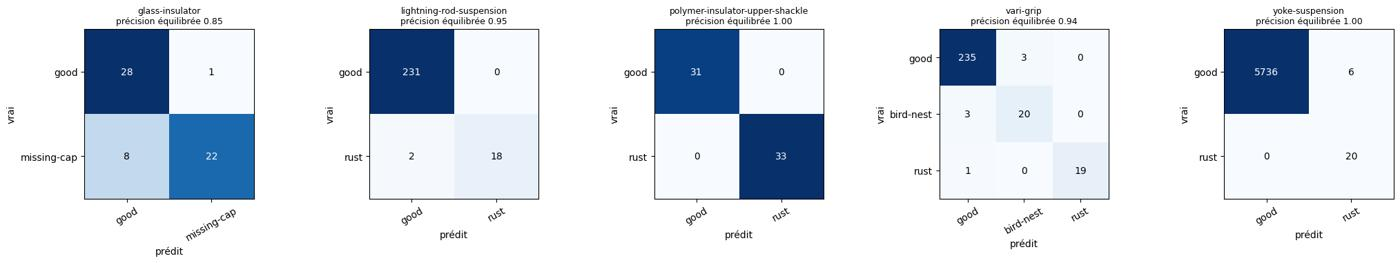

In [9]:
# Cellule 6 : tableau récapitulatif + matrices de confusion
import pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
tab = pd.DataFrame([{"équipement": eq, "classes": " / ".join(r["classes"]),
                     "précision équilibrée": r["precision_equilibree"],
                     "simple : défauts trouvés": r["regle_simple"]["defauts_trouves"],
                     "simple : fausses alertes": r["regle_simple"]["fausses_alertes"],
                     "seuil coût": r["seuil_cout_10"],
                     "coût : défauts trouvés": r["regle_cout"]["defauts_trouves"],
                     "coût : fausses alertes": r["regle_cout"]["fausses_alertes"]} for eq, r in resultats.items()])
print(tab.to_string(index=False))
tab.to_csv(f"{SORTIE}/tableau_defauts.csv", index=False)

fig, axs = plt.subplots(1, len(resultats), figsize=(4.2 * len(resultats), 3.8), squeeze=False)
for ax, (eq, r) in zip(axs[0], resultats.items()):
    cm = np.array(r["matrice_confusion"]); ax.imshow(cm, cmap="Blues")
    for i in range(len(cm)):
        for j in range(len(cm)):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(len(cm)), r["classes"], rotation=30); ax.set_yticks(range(len(cm)), r["classes"])
    ax.set_title(f"{eq}\nprécision équilibrée {r['precision_equilibree']:.2f}", fontsize=9)
    ax.set_xlabel("prédit"); ax.set_ylabel("vrai")
plt.tight_layout(); plt.savefig(f"{SORTIE}/matrices_confusion.png", dpi=110); plt.show()

## Explicabilité (Grad-CAM)
Zones de l'image qui influencent le plus la décision, sur des défauts du test.

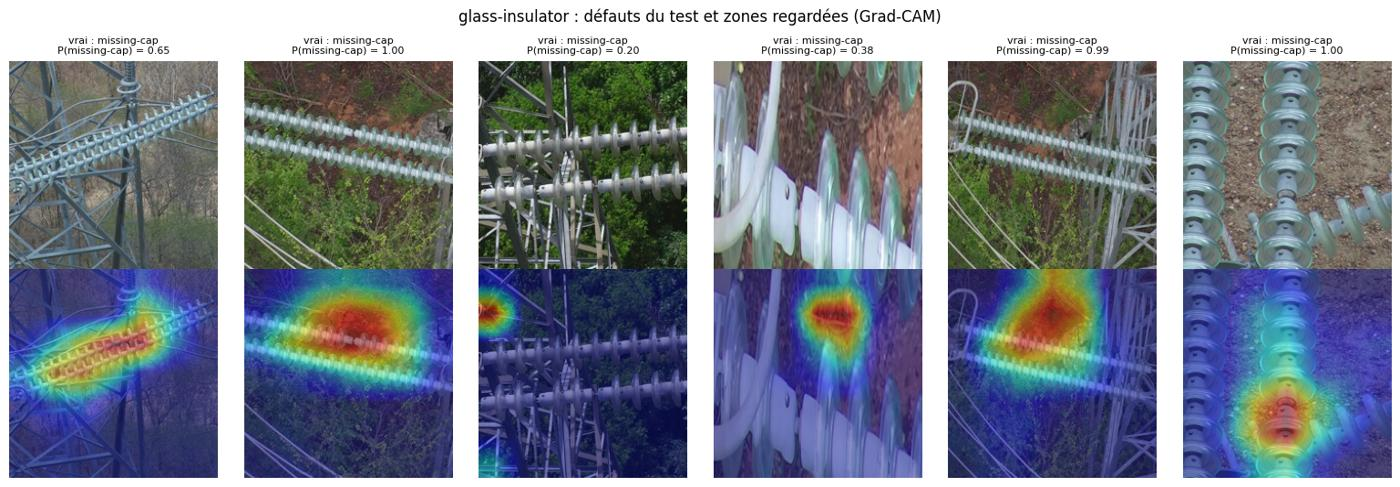

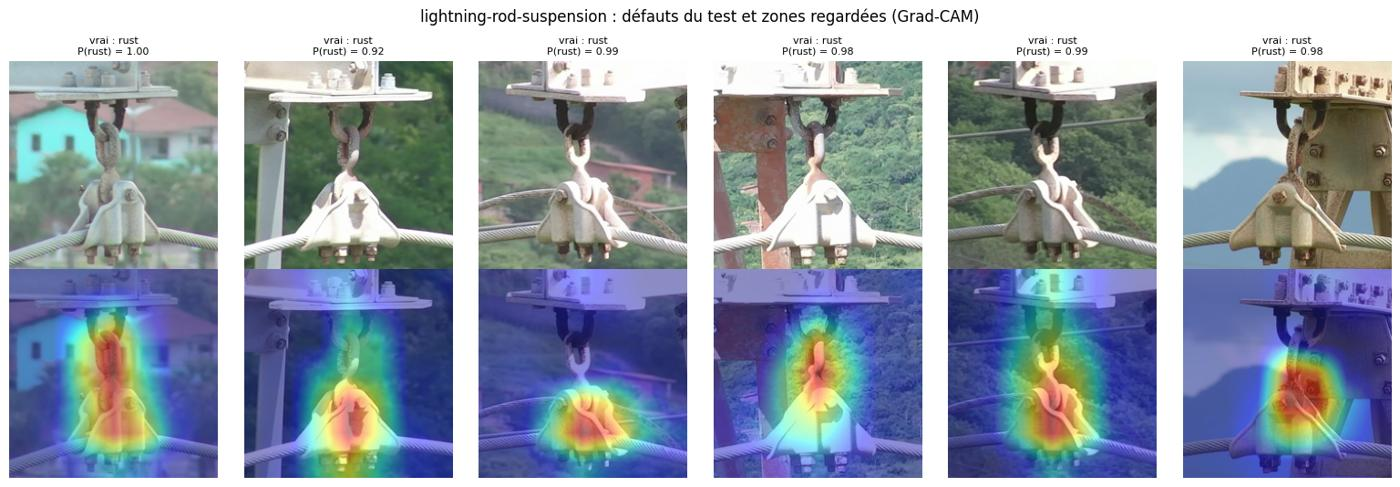

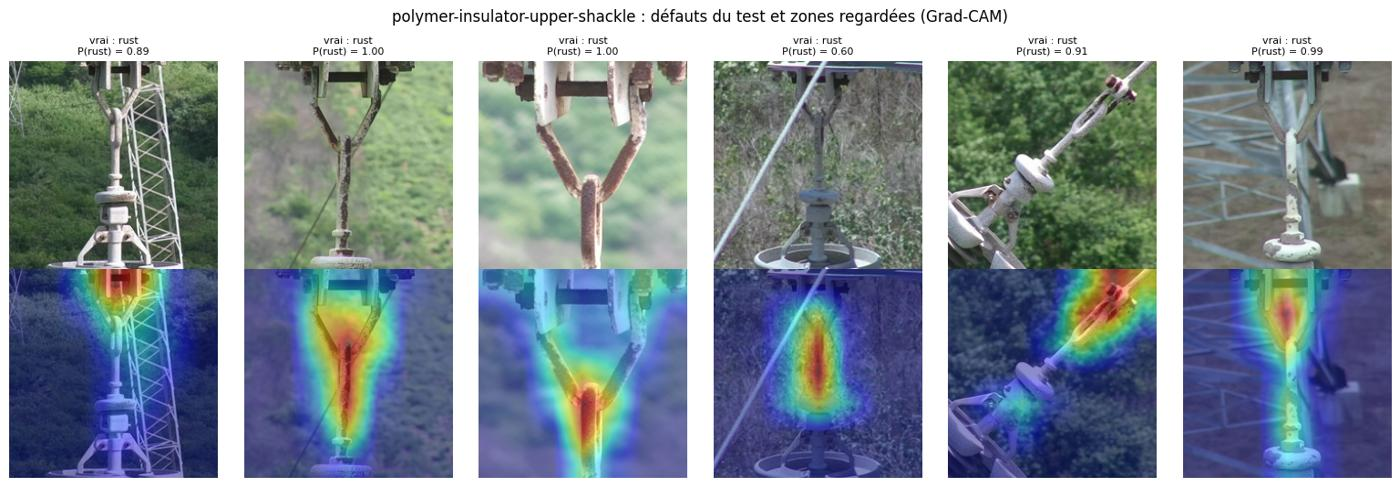

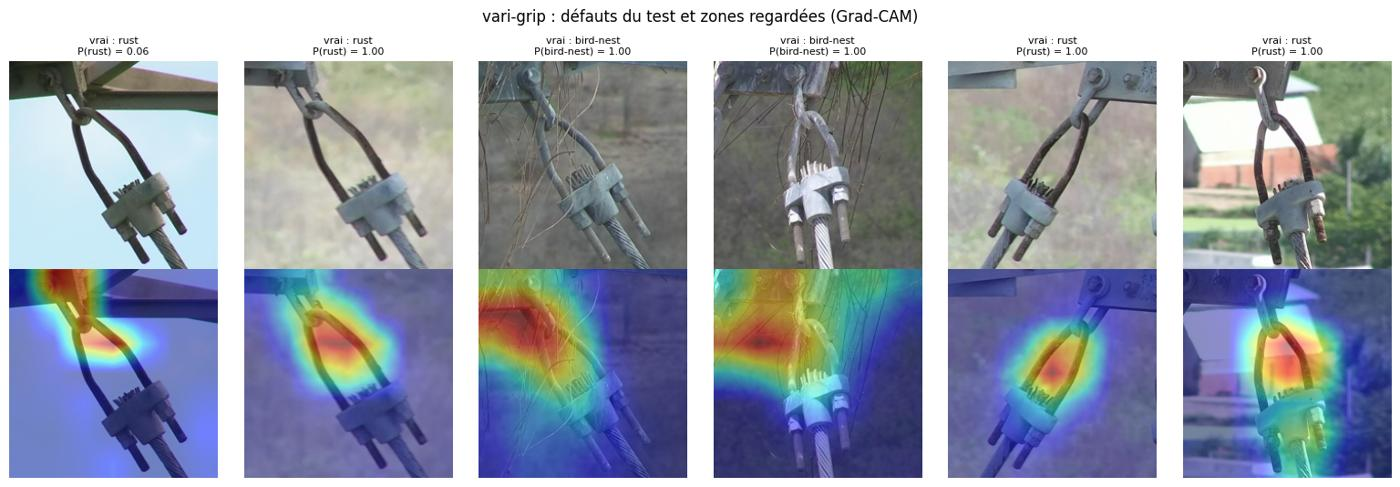

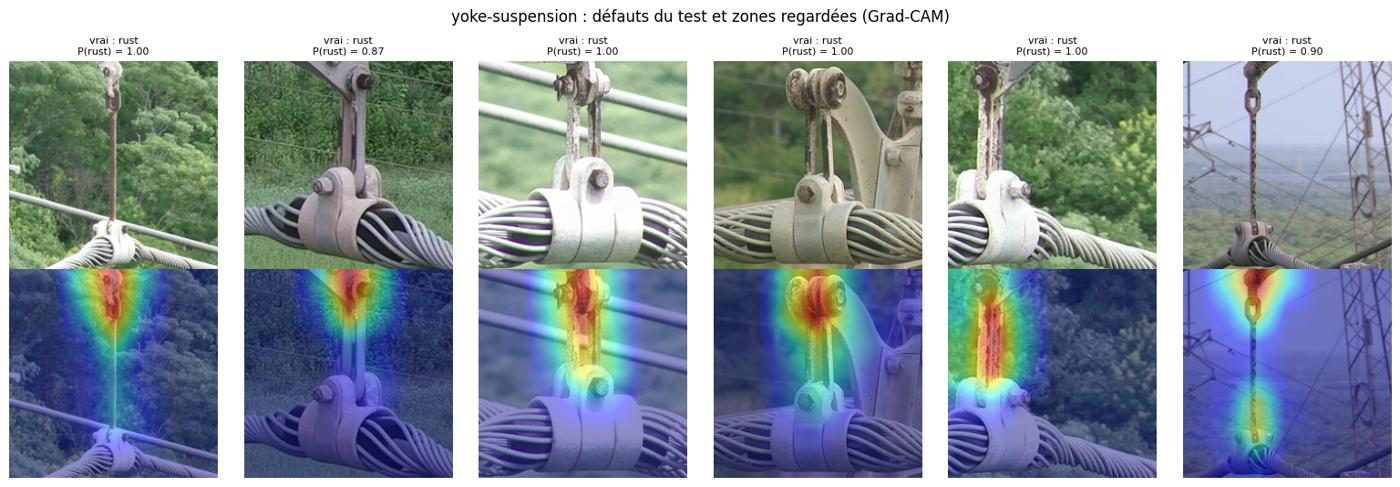

In [10]:
# Cellule 7 : Grad-CAM : le modèle regarde-t-il le défaut (rouille, nid) ou autre chose ?
def grad_cam(m, x, cible):
    m.eval(); acts = {}
    h = m.features[-1].register_forward_hook(lambda mod, i, o: acts.__setitem__("a", o))
    sortie = m(x); h.remove()
    a = acts["a"]; g = torch.autograd.grad(sortie[0, cible], a)[0]
    cam = F.relu((g.mean((2, 3), keepdim=True) * a).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)[0, 0]
    return (cam / (cam.max() + 1e-8)).detach().cpu().numpy()

for eq, (m, classes) in modeles.items():
    defauts = [(p, c) for p, c in donnees[eq]["val"] if c != "good"]
    choix = random.Random(0).sample(defauts, min(6, len(defauts)))
    if not choix: continue
    fig, axs = plt.subplots(2, len(choix), figsize=(2.6 * len(choix), 5.4), squeeze=False)
    for j, (p, c) in enumerate(choix):
        img = Image.open(p).convert("RGB").resize((TAILLE, TAILLE))
        x = SIMPLE(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE).requires_grad_(True)
        prob = F.softmax(m(x), 1)[0].detach().cpu().numpy()
        cam = grad_cam(m, x, classes.index(c))
        axs[0, j].imshow(img); axs[0, j].set_title(f"vrai : {c}\nP({c}) = {prob[classes.index(c)]:.2f}", fontsize=8)
        axs[1, j].imshow(img); axs[1, j].imshow(cam, cmap="jet", alpha=0.45)
        axs[0, j].axis("off"); axs[1, j].axis("off")
    fig.suptitle(f"{eq} : défauts du test et zones regardées (Grad-CAM)")
    plt.tight_layout(); plt.savefig(f"{SORTIE}/gradcam_{eq}.png", dpi=100); plt.show()

In [12]:
# Cellule 9 : la fuite gonfle-t-elle les scores ? On compare le test « photos déjà vues » vs « photos nouvelles »
for eq in donnees:
    print(eq, "| exemples de noms :", [os.path.basename(p) for p, _ in donnees[eq]["train"][:2]])
lignes = []
for eq, (m, classes) in modeles.items():
    d = donnees[eq]; ph_tr = {photo_id(p) for p, _ in d["train"]}
    te = d["val"]; y = np.array([classes.index(c) for _, c in te])
    pred = predire(m, te, classes).argmax(1)
    commun = np.array([photo_id(p) in ph_tr for p, _ in te])
    for nom, masque in [("photos déjà vues", commun), ("photos nouvelles", ~commun)]:
        if masque.sum() == 0: continue
        yy, pp = y[masque], pred[masque]
        lignes.append({"équipement": eq, "sous-ensemble": nom, "n": int(masque.sum()),
                       "classes": dict(collections.Counter(classes[i] for i in yy)),
                       "précision équilibrée": round(balanced_accuracy_score(yy, pp), 3) if len(set(yy)) > 1 else None,
                       "défauts trouvés": f"{int(((pp != 0) & (yy != 0)).sum())}/{int((yy != 0).sum())}",
                       "fausses alertes": f"{int(((pp != 0) & (yy == 0)).sum())}/{int((yy == 0).sum())}"})
tab9 = pd.DataFrame(lignes); print(tab9.to_string(index=False))
tab9.to_csv(f"{SORTIE}/fuite_par_sous_ensemble.csv", index=False)

glass-insulator | exemples de noms : ['Fotos 03-12-2020_DJI_0260_cadeia_isolador_vidro_819.jpg', 'Fotos 25-11-2020_DJI_0413_cadeia_isolador_vidro_1737.jpg']
lightning-rod-suspension | exemples de noms : ['Fotos 02-12-2020_DJI_0511_suspensao_para_raio_34.jpg', 'Fotos 25-11-2020_DJI_0462_suspensao_para_raio_633.jpg']
polymer-insulator-upper-shackle | exemples de noms : ['02-06-2021_DJI_0644_294_8.jpg', 'Fotos 19-10-2020_DJI_0085_manilha_isolador_superior_18_6.jpg']
vari-grip | exemples de noms : ['15-06-2021_DJI_0044_725.jpg', 'Fotos 25-11-2020_DJI_0586_vari_grip_846_7.jpg']
yoke-suspension | exemples de noms : ['Fotos 07-12-2020_DJI_0322_amarra_balancim_1169.jpg', 'Fotos 23-10-2020_DJI_0134_amarra_balancim_4837.jpg']
                     équipement    sous-ensemble    n                                    classes  précision équilibrée défauts trouvés fausses alertes
                glass-insulator photos déjà vues   11                        {'missing-cap': 11}                   NaN     

## Export des résultats

In [13]:
# Cellule 8 : préparer le zip des résultats
dossier = "/kaggle/working/resultats_defauts"; os.makedirs(dossier, exist_ok=True)
for f in glob.glob(f"{SORTIE}/*.png") + glob.glob(f"{SORTIE}/*.csv") + glob.glob(f"{SORTIE}/*.json"):
    shutil.copy(f, dossier)
shutil.make_archive(dossier, "zip", dossier)
print("Zip prêt : Output > /kaggle/working > resultats_defauts.zip")

Zip prêt : panneau de droite > Output > /kaggle/working > resultats_defauts.zip > ⋮ > Download
